In [1]:
pip install fuzzywuzzy pyphonetics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 3.7 MB/s eta 0:00:00


In [2]:
pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import sklearn as sk
from fuzzywuzzy import process
from itertools import groupby
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [4]:
df=pd.read_csv("/content/drive/MyDrive/Project Datasets/Credit Canada Dataset.csv")
df.head()

,id,DCP_activation_date,DCP_start_date,duration_of_dcp,DCP_drop_date,DCP_drop_status,gender_at_activation,marital_status_at_activation,age_at_activation,dependents_at_activation,...,pmtstatus03,pmtstatus04,pmtstatus05,pmtstatus06,pmtstatus07,pmtstatus08,pmtstatus09,pmtstatus10,pmtstatus11,pmtstatus12
0,67330,8/20/19,8/30/19,48,8/9/23,Successful Completion,Male,Married,59.0,0,...,zero,full,partial,zero,full,partial,partial,zero,partial,zero
1,69260,10/15/20,11/15/20,38,1/25/24,Non Payment,Female,Separated,63.0,0,...,partial,partial,full,partial,partial,partial,partial,partial,partial,partial
2,72183,3/21/22,4/24/22,29,9/20/24,Successful Completion,Female,Married,33.0,0,...,full,full,full,full,full,full,full,full,full,full
3,69494,3/12/22,4/24/22,22,2/28/24,Non Payment,Male,Married,36.0,3,...,partial,zero,zero,partial,partial,partial,partial,partial,partial,partial
4,67603,2/2/23,2/24/23,8,10/5/23,Non Payment,Female,Single,39.0,3,...,zero,zero,zero,zero,zero,zero,NaN,NaN,NaN,NaN


In [5]:
df.shape

(3212, 38)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3212 entries, 0 to 3211
Data columns (total 38 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    3212 non-null   int64  
 1   DCP_activation_date                   3212 non-null   object 
 2   DCP_start_date                        3212 non-null   object 
 3   duration_of_dcp                       3212 non-null   int64  
 4   DCP_drop_date                         3212 non-null   object 
 5   DCP_drop_status                       3212 non-null   object 
 6   gender_at_activation                  3212 non-null   object 
 7   marital_status_at_activation          3175 non-null   object 
 8   age_at_activation                     3193 non-null   float64
 9   dependents_at_activation              3212 non-null   int64  
 10  number_in_household_at_activation     3212 non-null   int64  
 11  housing_status_at

In [7]:
df.isna().sum()

,0
id,0
DCP_activation_date,0
DCP_start_date,0
duration_of_dcp,0
DCP_drop_date,0
DCP_drop_status,0
gender_at_activation,0
marital_status_at_activation,37
age_at_activation,19
dependents_at_activation,0


In [8]:
df.describe()

,id,duration_of_dcp,age_at_activation,dependents_at_activation,number_in_household_at_activation,asset_amount_owed_at_activation,asset_value_at_activation,monthly_income_at_activation,monthly_expenses_at_activation,DCP_debt_at_activation,DCP_debt_balance_at_activation,has_payday_debt_on_DCP_at_activation,payday_debt_balance_at_activation
count,3212.000000,3212.000000,3193.000000,3212.000000,3212.000000,3212.000000,3.212000e+03,3212.000000,3203.000000,3212.000000,3212.000000,3212.000000,3212.000000
mean,69100.754047,25.415940,40.389289,0.593711,2.142590,21904.768369,6.776705e+04,2998.198898,2596.765398,4.096513,16472.171071,0.385430,1897.278384
std,2118.489077,20.635167,14.251161,1.065993,1.410762,75467.659818,2.099377e+05,1656.604738,1495.992995,2.705525,17358.054908,0.486772,3933.746305
min,65986.000000,1.000000,19.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,1.000000,100.000000,0.000000,0.000000
25%,67176.750000,7.000000,29.000000,0.000000,1.000000,0.000000,5.000000e+02,1951.500000,1610.000000,2.000000,5438.482500,0.000000,0.000000
50%,69176.500000,19.000000,37.000000,0.000000,2.000000,0.000000,2.500000e+03,2713.580000,2348.000000,4.000000,10923.590000,0.000000,0.000000
75%,71286.000000,45.000000,50.000000,1.000000,3.000000,1.250000,2.000000e+04,3783.750000,3252.500000,5.000000,21289.005000,1.000000,2020.612500
max,72392.000000,93.000000,88.000000,16.000000,18.000000,728000.000000,5.011500e+06,24000.000000,23620.000000,24.000000,229612.870000,1.000000,40854.740000


In [9]:
# counting out unique values in the reason for DCP activation column
df["reason_for_DCP_at_activation"].value_counts()

,count
reason_for_DCP_at_activation,
Poor Money Management,398
Reduced Income/Unemployment,303
"Medical/Disability, Accident, Pregnancy",113
CARING FOR RELATIVES/FRIENDS,54
USED CREDIT FOR LIVING EXP.,53
Separation/Divorce/Family issues,53
Additional Expense - Death in Family,21
Creditor Harassment,21
Gambling Debt,16


In [10]:
# summing up rows by duration
df.groupby("duration_of_dcp")["duration_of_dcp"].count().sort_values(ascending=False).head(15)

,duration_of_dcp
duration_of_dcp,
4,173
3,162
2,144
5,120
7,120
6,108
1,91
8,91
9,87


In [11]:
# pivot table for gender vs dcp_drop status
pd.pivot_table(df,index="gender_at_activation",columns="DCP_drop_status",values="id",aggfunc="count")

DCP_drop_status,Bankruptcy,Consumer Proposal,Deceased,Non Payment,Self Administration,Successful Completion
gender_at_activation,,,,,,
Female,16.0,141.0,7.0,742.0,94.0,687.0
Male,15.0,88.0,2.0,675.0,69.0,539.0
Other/Not Reported,NaN,10.0,NaN,80.0,13.0,34.0


In [12]:
# pivot table for marital status vs dcp_drop status
pd.pivot_table(df,index="marital_status_at_activation",columns="DCP_drop_status",values="id",aggfunc="count")

DCP_drop_status,Bankruptcy,Consumer Proposal,Deceased,Non Payment,Self Administration,Successful Completion
marital_status_at_activation,,,,,,
Common Law/Domestic Partners,NaN,29.0,NaN,161.0,14.0,108.0
Divorced,5.0,14.0,NaN,66.0,5.0,78.0
Married,11.0,47.0,3.0,274.0,40.0,317.0
Separated,NaN,14.0,NaN,96.0,12.0,85.0
Single,13.0,116.0,6.0,851.0,102.0,633.0
Widowed,2.0,12.0,NaN,27.0,2.0,32.0


In [13]:
# pivot table for employment status vs dcp_drop status
pd.pivot_table(df,index="employment_status_at_activation",columns="DCP_drop_status",values="id",aggfunc="count")

DCP_drop_status,Bankruptcy,Consumer Proposal,Deceased,Non Payment,Self Administration,Successful Completion
employment_status_at_activation,,,,,,
Retired,9.0,20.0,5.0,57.0,9.0,117.0
Unemployed,7.0,30.0,1.0,250.0,34.0,216.0
Working Full-Time,10.0,149.0,2.0,843.0,85.0,763.0
Working Part-Time,3.0,12.0,NaN,166.0,20.0,114.0


In [14]:
# pivot table for housing status vs dcp_drop status
pd.pivot_table(df,index="housing_status_at_activation",columns="DCP_drop_status",values="id",aggfunc="count")

DCP_drop_status,Bankruptcy,Consumer Proposal,Deceased,Non Payment,Self Administration,Successful Completion
housing_status_at_activation,,,,,,
Own,2,19,5,138,30,233
Rent,29,220,4,1359,146,1027


In [15]:
# pivot table for # dependents vs dcp_drop status
pd.pivot_table(df,index="dependents_at_activation",columns="DCP_drop_status",values="id",aggfunc="count")

DCP_drop_status,Bankruptcy,Consumer Proposal,Deceased,Non Payment,Self Administration,Successful Completion
dependents_at_activation,,,,,,
0,27.0,170.0,8.0,980.0,130.0,870.0
1,2.0,32.0,NaN,229.0,20.0,186.0
2,1.0,25.0,1.0,175.0,17.0,130.0
3,1.0,8.0,NaN,75.0,5.0,52.0
4,NaN,4.0,NaN,24.0,2.0,14.0
5,NaN,NaN,NaN,8.0,2.0,4.0
6,NaN,NaN,NaN,5.0,NaN,3.0
7,NaN,NaN,NaN,NaN,NaN,1.0
16,NaN,NaN,NaN,1.0,NaN,NaN


In [16]:
# new field for age based on ranges
bins = [15, 25, 35, 45, 55, 65, 75, float('inf')]  # ranges starting from 15
df['age_group'] = pd.cut(df['age_at_activation'], bins=bins, right=False)

print(df)

         id DCP_activation_date DCP_start_date  duration_of_dcp DCP_drop_date  \
0     67330             8/20/19        8/30/19               48        8/9/23   
1     69260            10/15/20       11/15/20               38       1/25/24   
2     72183             3/21/22        4/24/22               29       9/20/24   
3     69494             3/12/22        4/24/22               22       2/28/24   
4     67603              2/2/23        2/24/23                8       10/5/23   
...     ...                 ...            ...              ...           ...   
3207  72378             7/26/24        9/24/24                1      10/21/24   
3208  72071             7/31/24        8/24/24                1        9/3/24   
3209  72383             8/20/24        9/24/24                1      10/22/24   
3210  72344             8/14/24        9/24/24                1      10/17/24   
3211  72246             8/23/24        9/24/24                1       10/2/24   

            DCP_drop_status

In [17]:
# if dcp_drop status = successful completion, then 1 else 0 for new field
df["dcp_success"]=np.where(df["DCP_drop_status"]=="Successful Completion",1,0)

In [18]:
df.head()

,id,DCP_activation_date,DCP_start_date,duration_of_dcp,DCP_drop_date,DCP_drop_status,gender_at_activation,marital_status_at_activation,age_at_activation,dependents_at_activation,...,pmtstatus05,pmtstatus06,pmtstatus07,pmtstatus08,pmtstatus09,pmtstatus10,pmtstatus11,pmtstatus12,age_group,dcp_success
0,67330,8/20/19,8/30/19,48,8/9/23,Successful Completion,Male,Married,59.0,0,...,partial,zero,full,partial,partial,zero,partial,zero,"[55.0, 65.0)",1
1,69260,10/15/20,11/15/20,38,1/25/24,Non Payment,Female,Separated,63.0,0,...,full,partial,partial,partial,partial,partial,partial,partial,"[55.0, 65.0)",0
2,72183,3/21/22,4/24/22,29,9/20/24,Successful Completion,Female,Married,33.0,0,...,full,full,full,full,full,full,full,full,"[25.0, 35.0)",1
3,69494,3/12/22,4/24/22,22,2/28/24,Non Payment,Male,Married,36.0,3,...,zero,partial,partial,partial,partial,partial,partial,partial,"[35.0, 45.0)",0
4,67603,2/2/23,2/24/23,8,10/5/23,Non Payment,Female,Single,39.0,3,...,zero,zero,zero,zero,NaN,NaN,NaN,NaN,"[35.0, 45.0)",0


In [19]:
df['dcp_success'].sum()

1260

In [20]:
# creating a pivot table for analysing age group and gender vs. dcp_drop_status vs sum and count from dcp_success
pd.pivot_table(df,index="age_group",columns="gender_at_activation",values="dcp_success",aggfunc=["sum","count"])

sum                          count       \
gender_at_activation Female Male Other/Not Reported Female Male   
age_group                                                         
[15.0, 25.0)             50   37                  3    148  139   
[25.0, 35.0)            198  199                  2    547  502   
[35.0, 45.0)            151  115                 10    369  304   
[45.0, 55.0)            139   87                  5    301  205   
[55.0, 65.0)             80   62                  7    168  146   
[65.0, 75.0)             51   30                  6    114   66   
[75.0, inf)              17    7                  1     34   19   

                                         
gender_at_activation Other/Not Reported  
age_group                                
[15.0, 25.0)                         18  
[25.0, 35.0)                         32  
[35.0, 45.0)                         34  
[45.0, 55.0)                         17  
[55.0, 65.0)                         15  
[65.0, 75.0)                         10  
[75.0, inf)                           5

In [21]:
# correlation matrix
round(df[["dcp_success","duration_of_dcp","age_at_activation","dependents_at_activation","number_in_household_at_activation","asset_amount_owed_at_activation","asset_value_at_activation",
    "monthly_income_at_activation", "monthly_expenses_at_activation","DCP_debt_at_activation","DCP_debt_balance_at_activation",
    "has_payday_debt_on_DCP_at_activation", "payday_debt_balance_at_activation"]].corr(),2)

,dcp_success,duration_of_dcp,age_at_activation,dependents_at_activation,number_in_household_at_activation,asset_amount_owed_at_activation,asset_value_at_activation,monthly_income_at_activation,monthly_expenses_at_activation,DCP_debt_at_activation,DCP_debt_balance_at_activation,has_payday_debt_on_DCP_at_activation,payday_debt_balance_at_activation
dcp_success,1.00,0.66,0.09,-0.03,0.00,0.19,0.05,-0.05,-0.05,-0.09,0.05,-0.16,-0.07
duration_of_dcp,0.66,1.00,0.15,-0.01,0.02,0.21,-0.00,-0.07,-0.07,-0.02,0.13,-0.12,-0.02
age_at_activation,0.09,0.15,1.00,-0.03,-0.05,0.13,0.18,0.10,0.06,0.02,0.20,0.00,0.10
dependents_at_activation,-0.03,-0.01,-0.03,1.00,0.73,0.10,0.09,0.32,0.33,0.09,0.08,0.00,-0.01
number_in_household_at_activation,0.00,0.02,-0.05,0.73,1.00,0.13,0.14,0.28,0.27,0.13,0.12,-0.01,0.02
asset_amount_owed_at_activation,0.19,0.21,0.13,0.10,0.13,1.00,0.51,0.21,0.21,0.07,0.27,-0.08,0.02
asset_value_at_activation,0.05,-0.00,0.18,0.09,0.14,0.51,1.00,0.30,0.27,0.09,0.33,-0.07,0.03
monthly_income_at_activation,-0.05,-0.07,0.10,0.32,0.28,0.21,0.30,1.00,0.96,0.32,0.51,0.03,0.14
monthly_expenses_at_activation,-0.05,-0.07,0.06,0.33,0.27,0.21,0.27,0.96,1.00,0.23,0.35,0.03,0.09
DCP_debt_at_activation,-0.09,-0.02,0.02,0.09,0.13,0.07,0.09,0.32,0.23,1.00,0.42,0.40,0.42


In [22]:
# creating a pivot for housing status vs. dcp_success vs. total count of rows
pd.pivot_table(df,index="housing_status_at_activation",values="dcp_success",aggfunc=["sum","count"])

,sum,count
,dcp_success,dcp_success
housing_status_at_activation,,
Own,233,427
Rent,1027,2785


In [23]:
# creating a pivot table for age group vs. gender with value as DCP_success
pd.pivot_table(df,index="gender_at_activation",columns="age_group",values="dcp_success",aggfunc=["sum","count"])

sum                                         \
age_group            [15.0, 25.0) [25.0, 35.0) [35.0, 45.0) [45.0, 55.0)   
gender_at_activation                                                       
Female                         50          198          151          139   
Male                           37          199          115           87   
Other/Not Reported              3            2           10            5   

                                                                  count  \
age_group            [55.0, 65.0) [65.0, 75.0) [75.0, inf) [15.0, 25.0)   
gender_at_activation                                                      
Female                         80           51          17          148   
Male                           62           30           7          139   
Other/Not Reported              7            6           1           18   

                                                                          \
age_group            [25.0, 35.0) [35.0, 45.0) [45.0, 55.0) [55.0, 65.0)   
gender_at_activation                                                       
Female                        547          369          301          168   
Male                          502          304          205          146   
Other/Not Reported             32           34           17           15   

                                               
age_group            [65.0, 75.0) [75.0, inf)  
gender_at_activation                           
Female                        114          34  
Male                           66          19  
Other/Not Reported             10           5

In [24]:
# all unique values in employment status at activation
df["employment_status_at_activation"].unique()

array(['Working Full-Time', 'Working Part-Time', 'Retired', 'Unemployed',
       nan], dtype=object)

In [25]:
# all unique values in occupation_at_activation
df["occupation_at_activation"].unique()

array(['truck driver (on WSIB)', 'DR PATAL', 'Housekeeper', ..., 'Crew',
       'General Helper', 'BOILER MAKER'], dtype=object)

Client Demographic Analysis

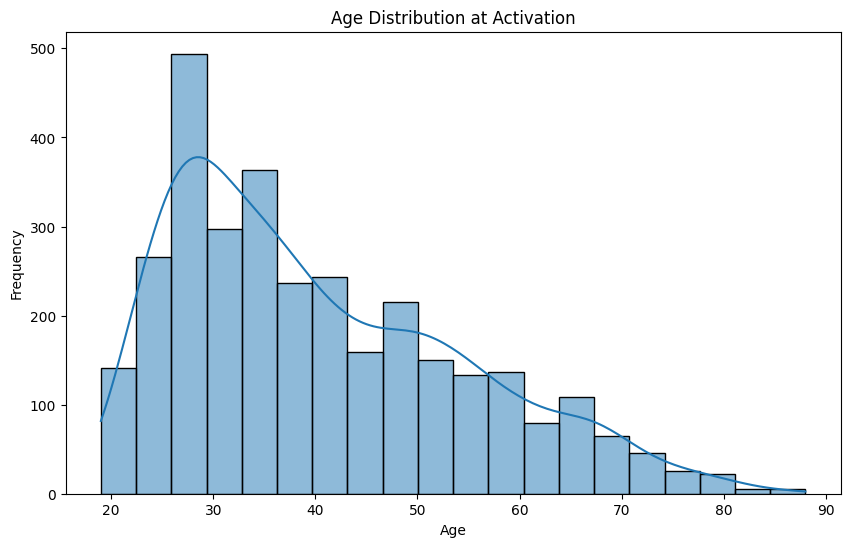

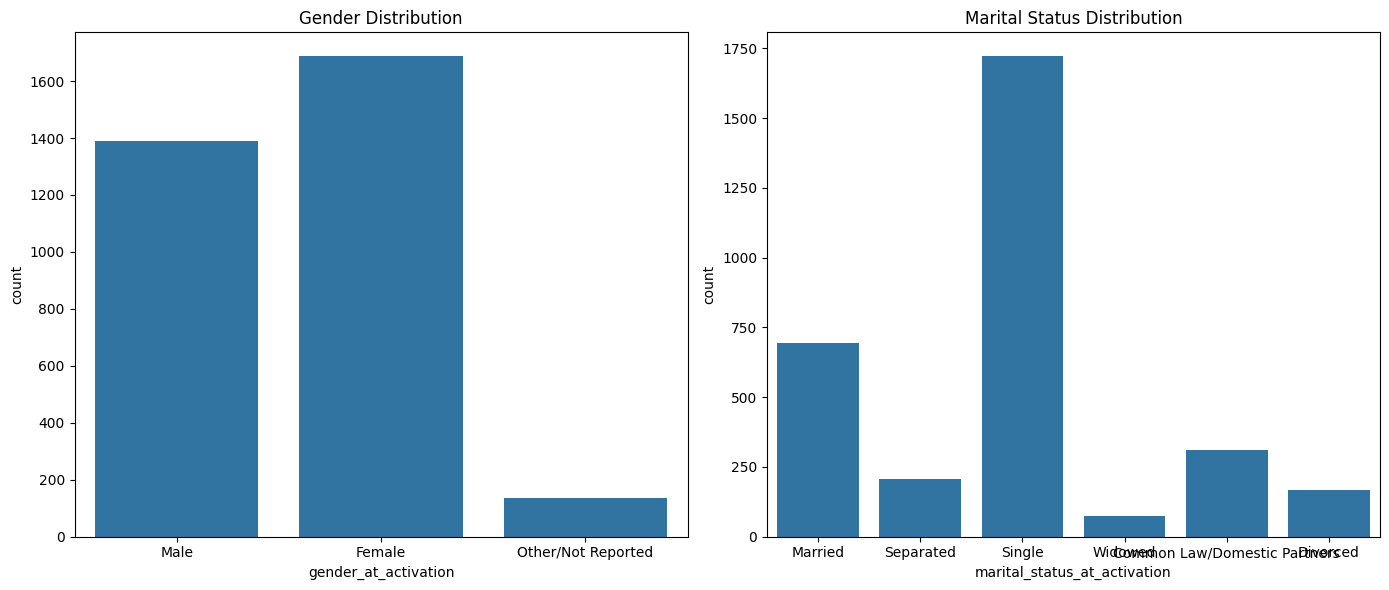

In [26]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age_at_activation'].dropna(), bins=20, kde=True)
plt.title("Age Distribution at Activation")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Gender and marital status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x='gender_at_activation', data=df, ax=axes[0])
axes[0].set_title("Gender Distribution")
sns.countplot(x='marital_status_at_activation', data=df, ax=axes[1])
axes[1].set_title("Marital Status Distribution")
plt.tight_layout()
plt.show()

Program Duration and Drop Analysis

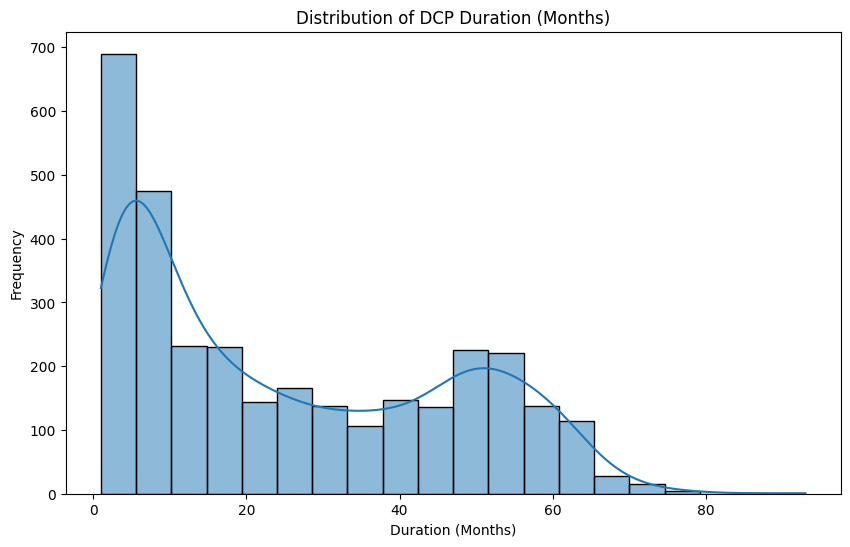

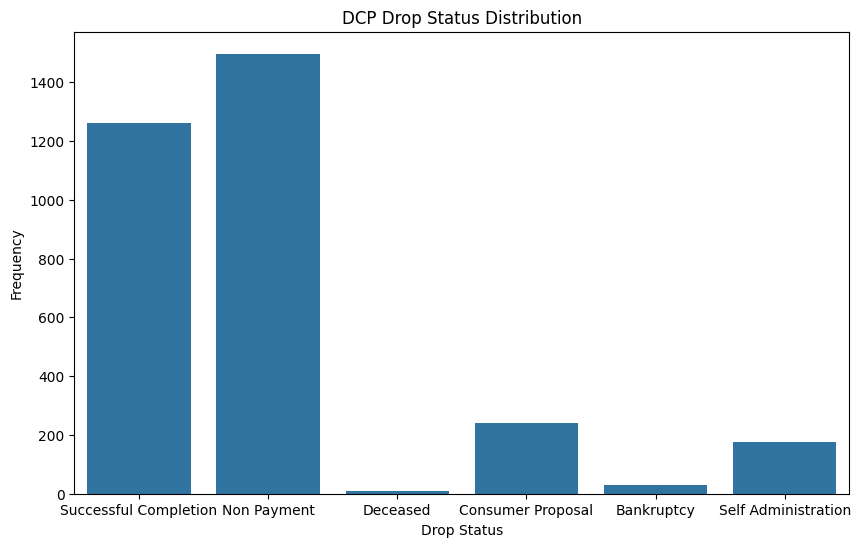

In [27]:
# Distribution of DCP duration
plt.figure(figsize=(10, 6))
sns.histplot(df['duration_of_dcp'], bins=20, kde=True)
plt.title("Distribution of DCP Duration (Months)")
plt.xlabel("Duration (Months)")
plt.ylabel("Frequency")
plt.show()

# Drop status analysis
plt.figure(figsize=(10, 6))
sns.countplot(x='DCP_drop_status', data=df)
plt.title("DCP Drop Status Distribution")
plt.xlabel("Drop Status")
plt.ylabel("Frequency")
plt.show()

Payment Behavior Analysis

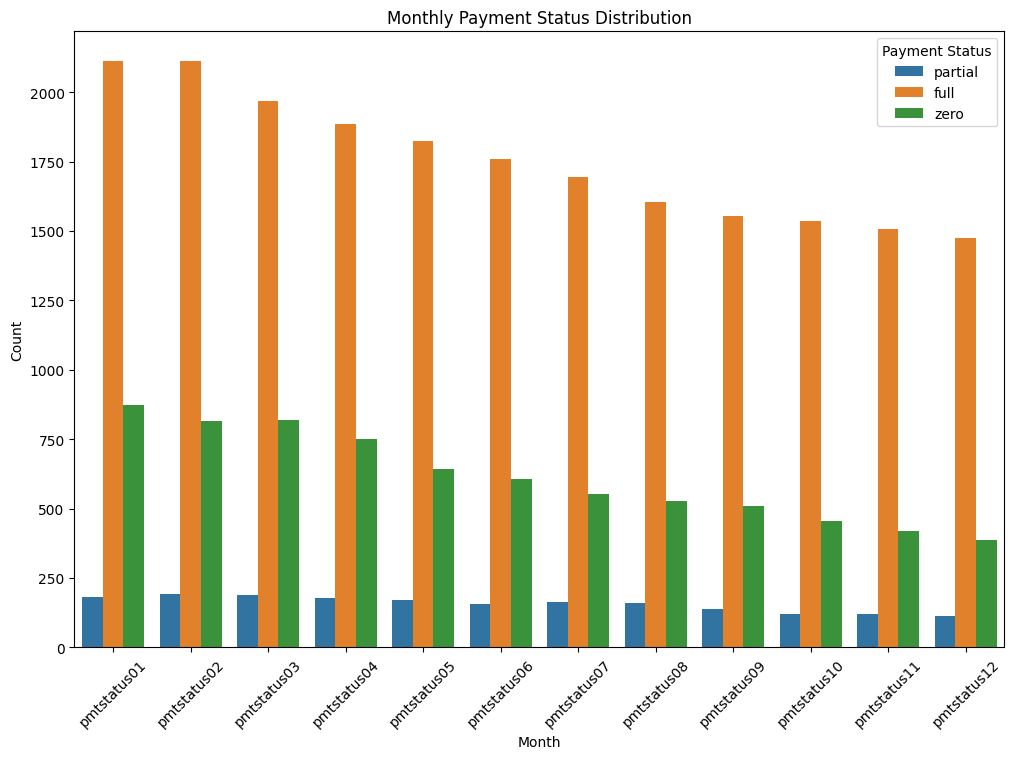

In [28]:
# Count of each payment status for the first few months
pmt_status_cols = [col for col in df.columns if 'pmtstatus' in col]

# Melt the data to analyze monthly payment statuses
pmt_data = df.melt(id_vars=['DCP_drop_status'], value_vars=pmt_status_cols,
                        var_name='Month', value_name='Payment_Status')

plt.figure(figsize=(12, 8))
sns.countplot(x='Month', hue='Payment_Status', data=pmt_data, order=pmt_status_cols)
plt.title("Monthly Payment Status Distribution")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Payment Status")
plt.show()

Date Based Analysis

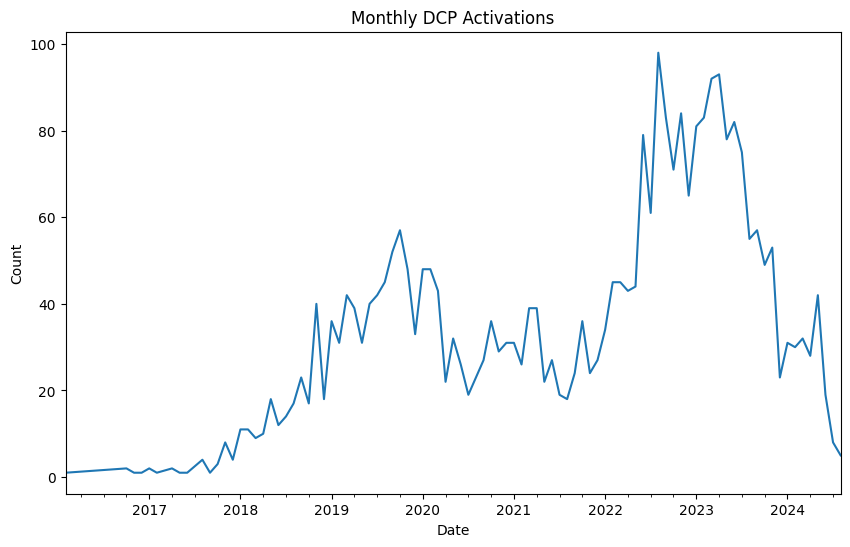

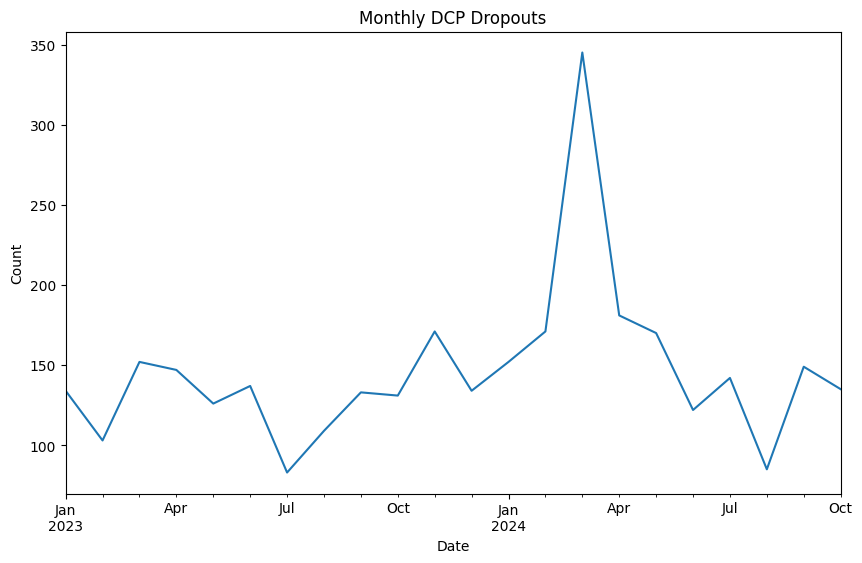

In [29]:
# Convert dates to datetime for analysis
df['DCP_activation_date'] = pd.to_datetime(df['DCP_activation_date'], errors='coerce')
df['DCP_start_date'] = pd.to_datetime(df['DCP_start_date'], errors='coerce')
df['DCP_drop_date'] = pd.to_datetime(df['DCP_drop_date'], errors='coerce')

# Activation trend over time
activation_trend = df.groupby(df['DCP_activation_date'].dt.to_period("M")).size()
activation_trend.plot(kind='line', figsize=(10, 6), title="Monthly DCP Activations", ylabel="Count", xlabel="Date")
plt.show()

# Drop trend over time
drop_trend = df.groupby(df['DCP_drop_date'].dt.to_period("M")).size()
drop_trend.plot(kind='line', figsize=(10, 6), title="Monthly DCP Dropouts", ylabel="Count", xlabel="Date")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Prepare data for modeling without 'duration_of_dcp' to avoid leakage
# You can include other relevant features, such as demographic or payment-related columns
X = df[['age_at_activation', 'dependents_at_activation', 'gender_at_activation']].fillna(0)
y = df['dcp_success']

# Convert categorical feature 'gender_at_activation' to numeric for modeling
X = pd.get_dummies(X, columns=['gender_at_activation'], drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.97      0.75       588
           1       0.44      0.04      0.07       376

    accuracy                           0.61       964
   macro avg       0.52      0.50      0.41       964
weighted avg       0.54      0.61      0.48       964



In [31]:
# Prepare data for modeling with payment status columns and other demographic features
# Here we're using the first three months of payment statuses as an example
X1 = df[['age_at_activation', 'dependents_at_activation', 'number_in_household_at_activation', 'gender_at_activation',
             'pmtstatus01', 'pmtstatus02', 'pmtstatus03']].fillna(0)
y1 = df['dcp_success']

# Convert categorical columns to numeric (one-hot encoding for 'gender_at_activation' and 'pmtstatus' columns)
X1 = pd.get_dummies(X1, columns=['gender_at_activation', 'pmtstatus01', 'pmtstatus02', 'pmtstatus03'], drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.25, random_state=42)

# Logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.62      0.70       475
           1       0.58      0.77      0.66       328

    accuracy                           0.68       803
   macro avg       0.69      0.69      0.68       803
weighted avg       0.71      0.68      0.68       803



In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Prepare the data
# Step 1: Exclude identifiers and any field that might directly indicate success
exclusion_list = ['id', 'DCP_drop_status', 'DCP_drop_date', 'duration_of_dcp']  # Adjust as needed
feature_columns = [col for col in df.columns if col not in exclusion_list]

# Step 2: Separate handling of missing values in numeric and categorical columns
X_numeric = X.select_dtypes(include=[np.number]).fillna(0)
X_categorical = X.select_dtypes(exclude=[np.number]).fillna('Unknown')

# Combine numeric and categorical data back into a single DataFrame
X = pd.concat([X_numeric, X_categorical], axis=1)

# Proceed with one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Continue with the rest of the feature selection code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Method 1: Random Forest Feature Importance
forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)
importance_scores = forest.feature_importances_

# Feature importance DataFrame
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance_scores})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("Top Features by Importance (Random Forest):")
print(feature_importance.head(20))

# Method 2: RFE with Logistic Regression
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=20)  # Adjust as needed
rfe.fit(X_train, y_train)

# Selected features from RFE
selected_features = X.columns[rfe.support_]
print("\nTop Features by RFE (Logistic Regression):")
print(selected_features)

Top Features by Importance (Random Forest):
                                   Feature  Importance
0                        age_at_activation    0.779761
1                 dependents_at_activation    0.160957
2                gender_at_activation_Male    0.033626
3  gender_at_activation_Other/Not Reported    0.025657

Top Features by RFE (Logistic Regression):
Index(['age_at_activation', 'dependents_at_activation',
       'gender_at_activation_Male', 'gender_at_activation_Other/Not Reported'],
      dtype='object')


In [33]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score

# Use only top features identified by RFE or Random Forest
# Replace 'selected_features' with top features identified in previous steps
X_selected = X[selected_features]

# Split data again using only selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# Train a logistic regression model using selected features
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Cross-validation to check model consistency
cv_scores = cross_val_score(model, X_selected, y, cv=5)
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.97      0.75       588
           1       0.44      0.04      0.07       376

    accuracy                           0.61       964
   macro avg       0.52      0.50      0.41       964
weighted avg       0.54      0.61      0.48       964

Accuracy: 0.6058091286307054
Cross-Validation Accuracy Scores: [0.60808709 0.60653188 0.60436137 0.59345794 0.59190031]
Mean CV Accuracy: 0.6008677199459309


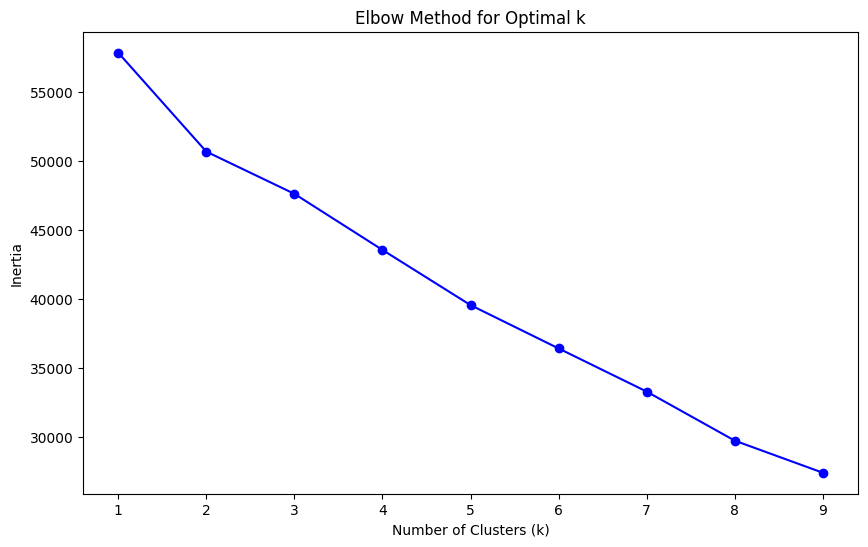

Cluster Analysis (Demographic Personas):
         age_at_activation  dependents_at_activation  \
Cluster                                                
0                43.650233                  1.322521   
1                41.465649                  0.503650   
2                38.554102                  0.205912   

         number_in_household_at_activation  monthly_income_at_activation  \
Cluster                                                                    
0                                 3.185357                   4081.408239   
1                                 2.277372                   3137.301314   
2                                 1.569639                   2403.088722   

         monthly_expenses_at_activation gender_at_activation  \
Cluster                                                        
0                           3551.744861               Female   
1                           2622.903577   Other/Not Reported   
2                           2077.123149  

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Select demographic features for clustering
demographic_features = ['age_at_activation', 'dependents_at_activation', 'number_in_household_at_activation',
                        'monthly_income_at_activation', 'monthly_expenses_at_activation', 'gender_at_activation',
                        'marital_status_at_activation', 'housing_status_at_activation', 'employment_status_at_activation']

# Prepare the data
X_demo = df[demographic_features].fillna(0)

# Step 2: One-hot encode categorical features and scale numeric features
X_demo = pd.get_dummies(X_demo, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_demo)

# Step 3: Determine the optimal number of clusters using the elbow method
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Step 4: Apply K-Means clustering with the chosen k (replace k=3 with the optimal k found)
optimal_k = 3  # Replace with the optimal number from the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Step 5: Analyze clusters
df['Cluster'] = clusters
# Separate numeric and categorical columns for aggregation
numeric_features = ['age_at_activation', 'dependents_at_activation', 'number_in_household_at_activation',
                    'monthly_income_at_activation', 'monthly_expenses_at_activation']
categorical_features = ['gender_at_activation', 'marital_status_at_activation',
                        'housing_status_at_activation', 'employment_status_at_activation']

# Calculate mean for numeric features within each cluster
cluster_numeric_summary = df.groupby('Cluster')[numeric_features].mean()

# Count categorical values within each cluster
cluster_categorical_summary = df.groupby('Cluster')[categorical_features].agg(lambda x: x.value_counts().index[0])

# Combine numeric and categorical summaries
cluster_analysis = pd.concat([cluster_numeric_summary, cluster_categorical_summary], axis=1)

print("Cluster Analysis (Demographic Personas):")
print(cluster_analysis)

In [35]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for the current clustering
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.18851626931990487


In [36]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    print(f"Silhouette Score for k={k}: {score}")

Silhouette Score for k=2: 0.17526468590145688
Silhouette Score for k=3: 0.18851626931990487
Silhouette Score for k=4: 0.17697317070742744
Silhouette Score for k=5: 0.18611601119122548
Silhouette Score for k=6: 0.20736773058190477
Silhouette Score for k=7: 0.2373885998321674
Silhouette Score for k=8: 0.24104330804870833
Silhouette Score for k=9: 0.2806961487828439


In [37]:
from sklearn.cluster import DBSCAN

# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust parameters as needed
clusters_dbscan = dbscan.fit_predict(X_scaled)
dbscan_score = silhouette_score(X_scaled, clusters_dbscan)
print("Silhouette Score with DBSCAN:", dbscan_score)

Silhouette Score with DBSCAN: -0.2152251777425683


In [38]:
from sklearn.decomposition import PCA

# Apply PCA to reduce features
pca = PCA(n_components=10)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_scaled)

# Re-run KMeans on PCA-transformed data
kmeans_pca = KMeans(n_clusters=9, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)
pca_score = silhouette_score(X_pca, clusters_pca)
print("Silhouette Score with PCA and KMeans:", pca_score)

Silhouette Score with PCA and KMeans: 0.33579835198909747


In [39]:
import pandas as pd
import re
from rapidfuzz import process, fuzz

In [40]:
occupation_groups = {
    'Administration & Office Support': [
        'admin', 'assistant', 'clerk', 'reception', 'receptionist', 'coordinator', 'secretary', 'office',
        'administrator', 'support', 'data entry', 'scheduler', 'document', 'a/p', 'renewal', 'team member',
        'program', 'key holder', 'stock', 'dispatch', 'clerical', 'clerical staff', 'front desk', 'exec asst'
    ],
    'Healthcare & Social Services': [
        'nurse', 'psw', 'health', 'social worker', 'therapist', 'care', 'support worker', 'paramedic',
        'disability', 'social services', 'aide', 'personal support worker', 'child', 'mental health',
        'rehabilitation', 'healthcare', 'care coordinator', 'rpn', 'physiotherapy', 'ecea', 'medical',
        'optician', 'synographer', 'fellow', 'ecg', 'medical esthetician', 'pab', 'dietary aid',
        'counsellor', 'addictions counsellor', 'community services', 'self-employed (photography)'
    ],
    'Technical & Skilled Trades': [
        'electrician', 'welder', 'mechanic', 'technician', 'plumber', 'machinist', 'operator',
        'repair', 'installer', 'assembler', 'hvac', 'apprentice', 'millwright', 'skilled trades',
        'quality control', 'cutter', 'butcher', 'sheet metal', 'dye setter', 'taper', 'grinderman',
        'miner', 'tool', 'mechanical', 'insulation', 'hairstylist', 'cosmetologist', 'carpenter',
        'steam fitter', 'boiler maker', 'infantryman'
    ],
    'Management & Supervisory Roles': [
        'manager', 'supervisor', 'director', 'lead', 'foreman', 'chief', 'head', 'executive',
        'vice president', 'mgr', 'operations manager', 'team leader', 'shift', 'supervisory',
        'lean specialist', 'asset protection', 'controller', 'property management', 'executive assistant'
    ],
    'Education & Childcare': [
        'teacher', 'educator', 'childcare', 'daycare', 'tutor', 'school', 'education', 'ece',
        'instructor', 'caring for kids', 'educ asst', 'registered ece', 'support worker',
        'learning specialist', 'language translator', 'teaching', 'inclusion resource', 'counselling dept'
    ],
    'Customer Service & Sales': [
        'customer service', 'sales', 'call centre', 'retail', 'cashier', 'advisor', 'agent',
        'associate', 'representative', 'sales rep', 'salesperson', 'consultant', 'csr', 'product',
        'client engagement', 'customer', 'advisor', 'external relations', 'renewal specialist',
        'reception', 'returns', 'instacart', 'interviewer', 'team member', 'service department', 'merchandiser'
    ],
    'Construction & Manual Labor': [
        'labor', 'construction', 'carpenter', 'roofer', 'painter', 'builder', 'brick', 'maintenance',
        'landscaping', 'gardener', 'pipe', 'installer', 'dry wall', 'concrete', 'plumbing', 'floor',
        'landscaper', 'renovations', 'moving company', 'yard', 'installing', 'interlocking',
        'manufacturing', 'flagger', 'roofing', 'scaffolding', 'custodian', 'cleaning'
    ],
    'Logistics & Transportation': [
        'driver', 'warehouse', 'shipper', 'receiver', 'logistics', 'distribution', 'delivery',
        'shipping', 'material', 'sorter', 'truck', 'packer', 'loader', 'crew', 'transit', 'courier',
        'baggage', 'bus', 'transportation', 'trucker', 'inventory', 'uber', 'fedex', 'recycling sorter',
        'ramp handler'
    ],
    'Creative & Media': [
        'photographer', 'designer', 'writer', 'content', 'videographer', 'editor', 'artist', 'media',
        'marketing', 'communications', 'content creator', 'production', 'film', 'creative', 'music',
        'performer', 'dancer', 'hallmark', 'interpreter', 'dj', 'life coach', 'external relations',
        'reporter', 'advertising', 'acting'
    ],
    'Hospitality & Food Service': [
        'cook', 'chef', 'waiter', 'barista', 'food', 'hotel', 'server', 'restaurant', 'bartender',
        'housekeeping', 'baker', 'dishwasher', 'cleaner', 'nanny', 'hostess', 'bar', 'costume buyer',
        'front of house', 'waitress', 'housekeeper', 'personal shopper'
    ],
    'Finance & Accounting': [
        'accountant', 'bookkeeper', 'financial', 'payroll', 'analyst', 'bank', 'treasurer',
        'auditor', 'account', 'tax', 'claims adjuster', 'accounts payable', 'estimator',
        'account executive', 'mortgage broker', 'insurance', 'stock', 'returns', 'credit operation'
    ],
    'Unemployed/Seeking Work': [
        'unemployed', 'job hunting', 'seeking employment', 'looking for work', 'ei', 'on e.i.',
        'applying for e.i', 'various jobs', 'on leave'
    ],
    'Temporary/Contract Work': [
        'temporary', 'contract', 'freelance', 'seasonal', 'ltd'
    ],
    'General Labor': [
        'labourer', 'helper', 'general labor', 'detailer'
    ],
    'Security & Protective Services': [
        'security', 'guard', 'flight operations', 'protective', 'safety', 'coast guard', 'fire fighter'
    ],
    'Health & Support Services': [
        'disabled', 'support', 'counsellor', 'companion', 'addictions counsellor', 'caregiver',
        'personal trainer', 'trainer'
    ],
    'Student/On Leave': [
        'student', 'mat leave', 'leave', 'full-time student', 'on e.i.'
    ],
    'Other/Miscellaneous': []  # Default category for unmatched entries
}

from fuzzywuzzy import process

def assign_category(occupation, threshold=80):
    if not occupation or occupation.isspace() or occupation.lower() in ['miscellaneous', 'various jobs', '']:
        return 'Other/Miscellaneous'

    occupation_lower = occupation.lower()
    best_category = 'Other/Miscellaneous'
    best_score = 0

    for category, keywords in occupation_groups.items():
        # Extract only the score
        match_result = process.extractOne(occupation_lower, keywords)
        if match_result:
            score = match_result[1]
            if score >= threshold and score > best_score:
                best_category = category
                best_score = score

    return best_category

# Apply the function to categorize occupations
df['occupation_group'] = df['occupation_at_activation'].str.lower().fillna('').apply(assign_category)

In [41]:
# listing out unique values in occupation_group and the number of candidates
pd.pivot_table(df,index="occupation_group",values="id",aggfunc="count")

,id
occupation_group,
Administration & Office Support,307
Construction & Manual Labor,83
Creative & Media,53
Customer Service & Sales,235
Education & Childcare,71
Finance & Accounting,49
General Labor,38
Health & Support Services,22
Healthcare & Social Services,349


In [42]:
# adding a third column in the above pivot table which does the division of column 1 by column 2
pivot=pd.pivot_table(df,index="occupation_group",values="dcp_success",aggfunc=["sum","count"])["sum"]/pd.pivot_table(df,index="occupation_group",values="dcp_success",aggfunc=["sum","count"])["count"]
pivot.sort_values(by='dcp_success',ascending=False)

,dcp_success
occupation_group,
Security & Protective Services,0.551724
Finance & Accounting,0.510204
Education & Childcare,0.507042
Management & Supervisory Roles,0.500000
Administration & Office Support,0.482085
General Labor,0.473684
Creative & Media,0.471698
Technical & Skilled Trades,0.461538
Health & Support Services,0.454545


In [43]:
# filtering for other/misc group and extracting 2 columns for it, occupation at activation and the group
df_test=df[df["occupation_group"]=="Other/Miscellaneous"][["occupation_at_activation","occupation_group"]]

In [44]:
# exporting dftest to csv
df_test.to_csv('df_test')

In [45]:
from pyphonetics import Metaphone

# Instantiate the Metaphone phonetic encoder
encoder = Metaphone()

# Phonetic occupation groups dictionary
occupation_groups_phonetic = {
    'Administration & Office Support': [encoder.phonetics(word) for word in [
        'admin', 'assistant', 'clerk', 'reception', 'receptionist', 'coordinator', 'secretary', 'office',
        'administrator', 'support', 'data entry', 'scheduler', 'document', 'a/p', 'renewal', 'team member',
        'program', 'key holder', 'stock', 'dispatch', 'clerical', 'clerical staff', 'front desk', 'exec asst'
    ]],
    'Healthcare & Social Services': [encoder.phonetics(word) for word in [
        'nurse', 'psw', 'health', 'social worker', 'therapist', 'care', 'support worker', 'paramedic',
        'disability', 'social services', 'aide', 'personal support worker', 'child', 'mental health',
        'rehabilitation', 'healthcare', 'care coordinator', 'rpn', 'physiotherapy', 'ecea', 'medical',
        'optician', 'synographer', 'fellow', 'ecg', 'medical esthetician', 'pab', 'dietary aid',
        'counsellor', 'addictions counsellor', 'community services', 'self-employed (photography)'
    ]],
    'Technical & Skilled Trades': [encoder.phonetics(word) for word in [
        'electrician', 'welder', 'mechanic', 'technician', 'plumber', 'machinist', 'operator',
        'repair', 'installer', 'assembler', 'hvac', 'apprentice', 'millwright', 'skilled trades',
        'quality control', 'cutter', 'butcher', 'sheet metal', 'dye setter', 'taper', 'grinderman',
        'miner', 'tool', 'mechanical', 'insulation', 'hairstylist', 'cosmetologist', 'carpenter'
    ]],
    'Management & Supervisory Roles': [encoder.phonetics(word) for word in [
        'manager', 'supervisor', 'director', 'lead', 'foreman', 'chief', 'head', 'executive',
        'vice president', 'mgr', 'operations manager', 'team leader', 'shift', 'supervisory',
        'lean specialist', 'asset protection', 'controller'
    ]],
    'Education & Childcare': [encoder.phonetics(word) for word in [
        'teacher', 'educator', 'childcare', 'daycare', 'tutor', 'school', 'education', 'ece',
        'instructor', 'caring for kids', 'educ asst', 'registered ece', 'support worker',
        'learning specialist', 'language translator', 'teaching', 'inclusion resource'
    ]],
    'Customer Service & Sales': [encoder.phonetics(word) for word in [
        'customer service', 'sales', 'call centre', 'retail', 'cashier', 'advisor', 'agent',
        'associate', 'representative', 'sales rep', 'salesperson', 'consultant', 'csr', 'product',
        'client engagement', 'customer', 'advisor', 'external relations', 'renewal specialist',
        'reception', 'returns', 'instacart', 'interviewer', 'team member'
    ]],
    'Construction & Manual Labor': [encoder.phonetics(word) for word in [
        'labor', 'construction', 'carpenter', 'roofer', 'painter', 'builder', 'brick', 'maintenance',
        'landscaping', 'gardener', 'pipe', 'installer', 'dry wall', 'concrete', 'plumbing', 'floor',
        'landscaper', 'renovations', 'moving company', 'yard', 'installing', 'interlocking',
        'manufacturing', 'flagger', 'roofing', 'scaffolding'
    ]],
    'Logistics & Transportation': [encoder.phonetics(word) for word in [
        'driver', 'warehouse', 'shipper', 'receiver', 'logistics', 'distribution', 'delivery',
        'shipping', 'material', 'sorter', 'truck', 'packer', 'loader', 'crew', 'transit', 'courier',
        'baggage', 'bus', 'transportation', 'trucker', 'inventory', 'uber', 'fedex', 'recycling sorter'
    ]],
    'Creative & Media': [encoder.phonetics(word) for word in [
        'photographer', 'designer', 'writer', 'content', 'videographer', 'editor', 'artist', 'media',
        'marketing', 'communications', 'content creator', 'production', 'film', 'creative', 'music',
        'performer', 'dancer', 'hallmark', 'interpreter', 'dj', 'life coach', 'external relations'
    ]],
    'Hospitality & Food Service': [encoder.phonetics(word) for word in [
        'cook', 'chef', 'waiter', 'barista', 'food', 'hotel', 'server', 'restaurant', 'bartender',
        'housekeeping', 'baker', 'dishwasher', 'cleaner', 'nanny', 'hostess', 'bar', 'costume buyer',
        'front of house', 'stay at home mom', 'stay at home father'
    ]],
    'Finance & Accounting': [encoder.phonetics(word) for word in [
        'accountant', 'bookkeeper', 'financial', 'payroll', 'analyst', 'bank', 'treasurer',
        'auditor', 'account', 'tax', 'claims adjuster', 'accounts payable', 'estimator',
        'account executive', 'mortgage broker', 'insurance', 'stock', 'returns'
    ]],
    'Government & Social Support': [encoder.phonetics(word) for word in [
        'cpp', 'odsp', 'oas', 'wsib', 'assistance', 'pension', 'retired', 'income', 'ontario works',
        'welfare', 'long-term disability', 'social security', 'cerb', 'canada response', 'aish',
        'employment insurance', 'crb', 'disability'
    ]],
    'Other/Miscellaneous': []  # Default category for unmatched entries
}



def assign_category_phonetic(occupation, threshold=80):
    if not occupation or occupation.isspace() or occupation.lower() in ['miscellaneous', 'various jobs', '']:
        return 'Other/Miscellaneous'

    occupation_phonetic = encoder.phonetics(occupation.lower())
    best_category = 'Other/Miscellaneous'
    best_score = 0

    for category, keywords_phonetic in occupation_groups_phonetic.items():
        # Match occupation with phonetic keywords using fuzzy matching
        match_result = process.extractOne(occupation_phonetic, keywords_phonetic)
        if match_result:
            score = match_result[1]
            if score >= threshold and score > best_score:
                best_category = category
                best_score = score

    return best_category

# Apply the function to categorize occupations
df['occupation_group'] = df['occupation_at_activation'].str.lower().fillna('').apply(assign_category_phonetic)

In [46]:
# listing out unique values in occupation_group and the number of candidates
pd.pivot_table(df,index="occupation_group",values="id",aggfunc="count")

,id
occupation_group,
Administration & Office Support,299
Construction & Manual Labor,99
Creative & Media,87
Customer Service & Sales,157
Education & Childcare,82
Finance & Accounting,46
Government & Social Support,340
Healthcare & Social Services,532
Hospitality & Food Service,161


In [47]:
# adding a third column in the above pivot table which does the division of column 1 by column 2
pivot=pd.pivot_table(df,index="occupation_group",values="dcp_success",aggfunc=["sum","count"])["sum"]/pd.pivot_table(df,index="occupation_group",values="dcp_success",aggfunc=["sum","count"])["count"]
pivot.sort_values(by='dcp_success',ascending=False)

,dcp_success
occupation_group,
Finance & Accounting,0.565217
Government & Social Support,0.535294
Management & Supervisory Roles,0.483193
Administration & Office Support,0.464883
Healthcare & Social Services,0.434211
Technical & Skilled Trades,0.433099
Education & Childcare,0.426829
Hospitality & Food Service,0.403727
Customer Service & Sales,0.388535


Early Warning System Proposal

In [48]:
df.columns

Index(['id', 'DCP_activation_date', 'DCP_start_date', 'duration_of_dcp',
       'DCP_drop_date', 'DCP_drop_status', 'gender_at_activation',
       'marital_status_at_activation', 'age_at_activation',
       'dependents_at_activation', 'number_in_household_at_activation',
       'housing_status_at_activation', 'employment_status_at_activation',
       'occupation_at_activation', 'postal_prefix_at_activation',
       'city_at_activation', 'province_at_activation',
       'reason_for_DCP_at_activation', 'asset_amount_owed_at_activation',
       'asset_value_at_activation', 'monthly_income_at_activation',
       'monthly_expenses_at_activation', 'DCP_debt_at_activation',
       'DCP_debt_balance_at_activation',
       'has_payday_debt_on_DCP_at_activation',
       'payday_debt_balance_at_activation', 'pmtstatus01', 'pmtstatus02',
       'pmtstatus03', 'pmtstatus04', 'pmtstatus05', 'pmtstatus06',
       'pmtstatus07', 'pmtstatus08', 'pmtstatus09', 'pmtstatus10',
       'pmtstatus11', 'pmtst

In [49]:
df.shape

(3212, 42)

In [50]:
# List of payment status columns
payment_columns = [f'pmtstatus{i:02d}' for i in range(1, 13)]

# Helper Function: Check if payment is "missed" (includes blank cells and "zero")
def is_missed(payment):
    return pd.isnull(payment) or payment == "zero"

# Determine when payment starts (first non-blank and non-NaN payment status)
def first_payment_start(row):
    for i, value in enumerate(row):
        if value in ["full", "partial", "zero"]:
            return i + 1  # Return 1-based index (month)
    return np.nan  # No payments made

# Total missed payments (count blanks and "zero" as missed after payment period starts)
def total_missed_payments(row):
    start = first_payment_start(row)
    if pd.isnull(start):  # If no payments started
        return 0
    return row[start - 1:].apply(is_missed).sum()

# Longest streak of consecutive missed payments (accounts for blanks and "zero")
def consecutive_missed_payments(row):
    start = first_payment_start(row)
    if pd.isnull(start):  # If no payments started
        return 0
    missed = row[start - 1:].apply(is_missed).tolist()
    return max((sum(1 for _ in group) for key, group in groupby(missed) if key), default=0)

# First missed payment month (includes blanks as missed)
def first_missed_payment_month(row):
    start = first_payment_start(row)
    if pd.isnull(start):  # If no payments started
        return np.nan
    for i, value in enumerate(row[start - 1:], start=start):
        if is_missed(value):
            return i  # Return 1-based month
    return np.nan

# Payment Ratio: Successful payments ("full" or "partial") vs total months after payment starts
def successful_payment_ratio(row):
    start = first_payment_start(row)
    if pd.isnull(start):  # If no payments started
        return 0
    total_months = len(row[start - 1:])
    successful_payments = row[start - 1:].apply(lambda x: x in ["full", "partial"]).sum()
    return successful_payments / total_months if total_months > 0 else 0

# DCP Dropped: Flag if all subsequent months are blank after payments started
def is_dropped(row):
    start = first_payment_start(row)
    if pd.isnull(start):  # If no payments started, assume DCP dropped
        return True
    subsequent_statuses = row[start - 1:]
    return subsequent_statuses.isnull().all()  # DCP is dropped if all subsequent statuses are blank

# Apply functions to the dataset
df['first_payment_month'] = df[payment_columns].apply(first_payment_start, axis=1)
df['missed_payments'] = df[payment_columns].apply(total_missed_payments, axis=1)
df['consecutive_missed'] = df[payment_columns].apply(consecutive_missed_payments, axis=1)
df['first_missed_month'] = df[payment_columns].apply(first_missed_payment_month, axis=1)
df['payment_ratio'] = df[payment_columns].apply(successful_payment_ratio, axis=1)
df['dcp_dropped'] = df[payment_columns].apply(is_dropped, axis=1)

# Save the updated dataset
df.to_csv('processed_dataset.csv', index=False)

# Check the derived features
df[['first_payment_month', 'missed_payments', 'consecutive_missed', 'first_missed_month', 'payment_ratio', 'dcp_dropped']].head()

,first_payment_month,missed_payments,consecutive_missed,first_missed_month,payment_ratio,dcp_dropped
0,1.0,5,2,2.0,0.583333,False
1,1.0,0,0,NaN,1.000000,False
2,1.0,1,1,1.0,0.916667,False
3,1.0,2,2,4.0,0.833333,False
4,1.0,11,10,1.0,0.083333,False


In [51]:
# Select features and target
features = ['missed_payments', 'consecutive_missed', 'payment_ratio', 'first_missed_month']
X = df[features]  # Replace with actual feature columns
y = df['dcp_success']  # Target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict dropout risk
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of dropout

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba))

# Add risk scores to the dataset
X_test['dropout_risk'] = y_proba
X_test['risk_level'] = pd.cut(y_proba, bins=[0, 0.4, 0.7, 1], labels=['Low', 'Moderate', 'High'])
print(X_test[['dropout_risk', 'risk_level']])

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81       588
           1       0.68      0.79      0.73       376

    accuracy                           0.77       964
   macro avg       0.77      0.78      0.77       964
weighted avg       0.78      0.77      0.78       964

AUC-ROC Score: 0.8390278983934
      dropout_risk risk_level
705       0.557636   Moderate
1871      0.162561        Low
3101      0.003027        Low
2585      0.097697        Low
3140      0.003027        Low
...            ...        ...
1626      0.024000        Low
2503      0.003027        Low
1161      0.762485       High
1073      0.615552   Moderate
1491      0.557636   Moderate

[964 rows x 2 columns]


In [52]:
# Define thresholds for personas
def assign_persona(row):
    # Successful personas
    if row['dcp_success'] == 1:  # Successful Completion
        if row['missed_payments'] <= 2 and row['payment_ratio'] >= 0.8 and row['consecutive_missed'] <= 1:
            return "Disciplined Completer"
        elif row['missed_payments'] > 2 and row['payment_ratio'] >= 0.6 and row['consecutive_missed'] <= 2:
            return "Adaptive Improver"

    # Unsuccessful personas
    elif row['dcp_success'] == 0:  # Dropout
        if row['missed_payments'] > 6 or row['payment_ratio'] < 0.3 or row['consecutive_missed'] >= 3:
            return "Early Dropout"
        elif row['missed_payments'] > 4 and row['payment_ratio'] >= 0.3 and row['consecutive_missed'] >= 2:
            return "Gradual Dropout"

    # Default persona if none of the conditions match
    return "Undefined"

# Apply the persona assignment to each row
df['persona'] = df.apply(assign_persona, axis=1)

# Check the distribution of personas
persona_counts = df['persona'].value_counts()
print("Persona Distribution:\n", persona_counts)

# Save the dataset with personas
df.to_csv('dataset_with_personas.csv', index=False)

# Optional: View a sample of the data with personas
print(df[['dcp_success', 'missed_payments', 'payment_ratio', 'consecutive_missed', 'persona']].head())

Persona Distribution:
 persona
Early Dropout            1338
Disciplined Completer    1019
Undefined                 753
Adaptive Improver          79
Gradual Dropout            23
Name: count, dtype: int64
   dcp_success  missed_payments  payment_ratio  consecutive_missed  \
0            1                5       0.583333                   2   
1            0                0       1.000000                   0   
2            1                1       0.916667                   1   
3            0                2       0.833333                   2   
4            0               11       0.083333                  10   

                 persona  
0              Undefined  
1              Undefined  
2  Disciplined Completer  
3              Undefined  
4          Early Dropout  


In [53]:
df.columns

Index(['id', 'DCP_activation_date', 'DCP_start_date', 'duration_of_dcp',
       'DCP_drop_date', 'DCP_drop_status', 'gender_at_activation',
       'marital_status_at_activation', 'age_at_activation',
       'dependents_at_activation', 'number_in_household_at_activation',
       'housing_status_at_activation', 'employment_status_at_activation',
       'occupation_at_activation', 'postal_prefix_at_activation',
       'city_at_activation', 'province_at_activation',
       'reason_for_DCP_at_activation', 'asset_amount_owed_at_activation',
       'asset_value_at_activation', 'monthly_income_at_activation',
       'monthly_expenses_at_activation', 'DCP_debt_at_activation',
       'DCP_debt_balance_at_activation',
       'has_payday_debt_on_DCP_at_activation',
       'payday_debt_balance_at_activation', 'pmtstatus01', 'pmtstatus02',
       'pmtstatus03', 'pmtstatus04', 'pmtstatus05', 'pmtstatus06',
       'pmtstatus07', 'pmtstatus08', 'pmtstatus09', 'pmtstatus10',
       'pmtstatus11', 'pmtst

In [54]:
# Select features and target
numerical_features = [
    'age_at_activation', 'monthly_income_at_activation', 'monthly_expenses_at_activation',
    'DCP_debt_balance_at_activation', 'payday_debt_balance_at_activation',
    'missed_payments', 'payment_ratio', 'consecutive_missed', 'first_missed_month'
]
categorical_features = [
    'gender_at_activation', 'employment_status_at_activation', 'marital_status_at_activation',
    'housing_status_at_activation', 'reason_for_DCP_at_activation'
]
target = 'dcp_success'

# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing values with median
    ('scaler', StandardScaler())                   # Scale numerical features
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),  # Fill missing with "Unknown"
    ('onehot', OneHotEncoder(handle_unknown='ignore'))                      # One-hot encode categorical features
])

# Combine preprocessors in a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Define the model
model = RandomForestClassifier(random_state=42)

# Create the full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# Split the data
X = df[numerical_features + categorical_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the model
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probability of dropout

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82       588
           1       0.70      0.77      0.73       376

    accuracy                           0.78       964
   macro avg       0.77      0.78      0.77       964
weighted avg       0.79      0.78      0.78       964

AUC-ROC Score: 0.8637623932551745
